# Processing raw bird data

based on the folder structure in the cloud bucket: 


└── YYYY_MM_DD-session_0001/           # Unique session folder


├── thermal_1/                                          # Thermal camera 1 data
│   ├── cameraSerial.csq                      
│   ├── cameraSerial_vmin-vmax.mp4                   
│   └── metadata.json                              # Metadata for thermal_cam_1



├── thermal_2/                                         # Thermal camera 2 data
│   ├── cameraSerial.csq                     
│   ├── cameraSerial_vmin-vmax.mp4                   
│   └── metadata.json                             # Metadata for thermal_cam_2



├── rgb_1/                                       # RGB camera 1 data
│   ├── cameraSerial.mp4



├── rgb_2/                                      # RGB camera 2 data
│   ├── cameraSerial.mp4



├── splats_cam/                                      # Splats

├── Metadata.yaml                                 # metadata and notes 


In [1]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
import cv2
from tqdm import tqdm
from ultralytics import YOLO
import yaml
import random
import shutil
import tempfile
from typing import List, Optional, Dict, Tuple
import logging
from dataclasses import dataclass
from datetime import datetime

# Setup logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger(__name__)

In [2]:
# Import from the scripts folder (locally these are all on my desktop lol) 

from Desktop.labeling_data.yolo.thermal_export import process_directory
from Desktop.labeling_data.timestamps import get_creation_time, extract_timestamps_from_folder
from Desktop.labeling_data.time_alignment import (
    extract_ffmpeg_timecode, rgb_timecode_to_ms, csq_filename_to_ms, 
    trim_video, trim_video_pair, match_rgb_to_thermal, trim_session)
from Desktop.labeling_data.collect_thermal_mp4s import collect_thermal_mp4s
from Desktop.labeling_data.yolo.frame_extraction import extract_frames_from_folder


This code processes videos of animals in the wild that were recorded with both thermal cameras and regular RGB cameras. The goal is to synchronize these videos in time and extract frames for further analysis.



In [5]:
@dataclass
class ProcessingConfig:
    """Configuration for video processing pipeline"""
    src_root_dir: Path
    target_root_dir: Path
    thermal_color: str = 'magma'
    preview: bool = True
    max_frames: int = 20000
    fps: int = 30
    target_fps: int = 15
    max_diff_ms: int = 70000

class AnimalVideoProcessor:
    """Main class for processing animal behavior videos"""
    
    def __init__(self, config: ProcessingConfig):
        self.config = config
        self.ensure_directories()
    
    def ensure_directories(self):
        """Create necessary directories if they don't exist"""
        self.config.target_root_dir.mkdir(parents=True, exist_ok=True)
        logger.info(f"Working directory: {self.config.target_root_dir}")
    
    def get_sessions(self, date_pattern: str = None) -> List[Path]:
        """Get all session directories matching the pattern"""
        if date_pattern is None:
            # Get all session directories
            pattern = "*-session_*"
        else:
            pattern = f"{date_pattern}-session_*"
        
        sessions = sorted([
            p for p in self.config.target_root_dir.iterdir() 
            if p.is_dir() and p.name.startswith(date_pattern or "") and "session_" in p.name
        ])
        
        logger.info(f"Found {len(sessions)} sessions matching pattern: {pattern}")
        return sessions
    
    def process_session_thermals(self, session_path: Path, operation: str, **kwargs) -> bool:
        """Generic method to process thermal cameras in a session"""
        success = True
        
        if operation == "temporal_alignment":
            # Special handling for temporal alignment - needs both RGB and thermal
            return self._process_temporal_alignment_session(session_path, **kwargs)
        elif operation == "session_frame_extraction":
            # Special handling for session-wide frame extraction
            return self._process_frames_session(session_path, **kwargs)
        
        for thermal_sub in ["thermal_1", "thermal_2"]:
            video_folder = session_path / thermal_sub
            
            if not video_folder.exists():
                logger.warning(f"Skipping missing folder: {video_folder}")
                continue
            
            logger.info(f"Processing {session_path.name} — {thermal_sub}")
            
            try:
                if operation == "csq_processing":
                    self._process_csq(video_folder, **kwargs)
                elif operation == "frame_extraction":
                    self._process_frame_extraction(video_folder, **kwargs)
                else:
                    logger.error(f"Unknown operation: {operation}")
                    success = False
                    
            except Exception as e:
                logger.error(f"Error processing {video_folder}: {e}")
                success = False
        
        return success
    
    def _process_csq(self, video_folder: Path, **kwargs):
        """Process CSQ files in thermal folder"""
        process_directory(
            video_folder, 
            video_folder, 
            color=self.config.thermal_color,
            preview=self.config.preview,
            max_frames=self.config.max_frames,
            fps=self.config.fps
        )
    
    def _process_temporal_alignment(self, video_folder: Path, **kwargs):
        """Process temporal alignment for thermal videos"""
        trim_session(video_folder, video_folder)
    
    def _process_temporal_alignment_session(self, session_path: Path, **kwargs) -> bool:
        """Process temporal alignment for entire session (RGB + thermal pairs)"""
        try:
            logger.info(f"Processing temporal alignment for session: {session_path.name}")
            trim_session(session_path)
            return True
        except Exception as e:
            logger.error(f"Error in temporal alignment for {session_path}: {e}")
            return False

    def _process_frames_session(self, session_path: Path, **kwargs) -> bool:
        """Extract frames for entire session (RGB + thermal pairs)"""
        try:
            logger.info(f"Processing frames for session: {session_path.name}")
            success = True
            
            # Process all camera folders in the session
            camera_folders = ["thermal_1", "thermal_2", "rgb_1", "rgb_2"]
            
            for camera_folder in camera_folders:
                video_folder = session_path / camera_folder
                
                if not video_folder.exists():
                    logger.warning(f"Skipping missing folder: {video_folder}")
                    continue
                    
                logger.info(f"Processing frames for {camera_folder}")
                
                # Check for time-cropped videos in this folder
                time_cropped_videos = list(video_folder.glob("time_cropped-*.mp4"))
                
                if time_cropped_videos:
                    logger.info(f"Found time-cropped videos in {camera_folder}: {[v.name for v in time_cropped_videos]}")
                    # Use both the thermal and rgb cropped videos and make folders for their frames
                    for video in time_cropped_videos:
                        self._extract_frames_from_video(video, video_folder, camera_folder)
                else:
                    logger.info(f"No time-cropped videos found in {camera_folder}, using original processing")
                    # Fall back to original frame extraction method
                    if "thermal" in camera_folder:
                        self._process_frame_extraction(video_folder, **kwargs)
                    else:
                        self._process_rgb_frame_extraction(video_folder, **kwargs)
                        
            return success
            
        except Exception as e:
            logger.error(f"Error in session frame extraction for {session_path}: {e}")
            return False

    def _extract_frames_from_video(self, video_path: Path, video_folder: Path, camera_type: str):
        """Extract frames from a specific video file"""
        # Create output folder named after the video
        video_stem = video_path.stem
        output_folder = video_folder / f"extracted_frames_{video_stem}"
        output_folder.mkdir(parents=True, exist_ok=True)
        
        logger.info(f"Extracting frames from {video_path.name} to {output_folder}")
        
        # Use the appropriate extraction method based on camera type
        if "thermal" in camera_type:
            # For thermal cameras, use existing thermal extraction logic
            extract_frames_from_video(
                video_path,
                output_folder,
                target_fps=self.config.target_fps
            )
        else:
            # For RGB cameras, use standard video frame extraction
            extract_frames_from_video(
                video_path,
                output_folder,
                target_fps=self.config.target_fps
            )

    def _process_rgb_frame_extraction(self, video_folder: Path, **kwargs):
        """Extract frames from RGB videos"""
        output_folder = video_folder / "extracted_frames"
        output_folder.mkdir(parents=True, exist_ok=True)
        
        # Look for MP4 files in RGB folder
        rgb_videos = list(video_folder.glob("*.mp4"))
        
        if rgb_videos:
            logger.info(f"Found RGB videos: {[v.name for v in rgb_videos]}")
            for video in rgb_videos:
                logger.info(f"Extracting frames from RGB video: {video.name}")
                extract_frames_from_video(
                    video,
                    output_folder,
                    target_fps=self.config.target_fps
                )
        else:
            logger.warning(f"No RGB videos found in {video_folder}")
            
    def _process_frame_extraction(self, video_folder: Path, **kwargs):
        """Extract frames from thermal videos (use time-cropped videos if available)"""
        output_folder = video_folder / "extracted_frames"
        output_folder.mkdir(parents=True, exist_ok=True)
        
        # Look for time-cropped videos first, then fall back to regular videos
        time_cropped_videos = list(video_folder.glob("time_cropped-*.mp4"))
        if time_cropped_videos:
            logger.info(f"Found time-cropped videos: {[v.name for v in time_cropped_videos]}")
            
            # Process each time-cropped video
            for video in time_cropped_videos:
                logger.info(f"Extracting frames from time-cropped video: {video.name}")
                
                # Create subfolder for this specific video
                video_output_folder = output_folder / video.stem
                video_output_folder.mkdir(parents=True, exist_ok=True)
                
                # Extract frames from this specific video
                extract_frames_from_video(
                    video,
                    video_output_folder,
                    target_fps=self.config.target_fps
                )
        else:
            logger.info("No time-cropped videos found, using original thermal processing")
            
            # Use the existing thermal extraction logic
            extract_frames_from_folder(
                video_folder, 
                output_folder, 
                target_fps=self.config.target_fps
            )
    
    def process_all_sessions(self, date_pattern: str = None, operations: List[str] = None):
        """Process all sessions with specified operations"""
        if operations is None:
            operations = ["csq_processing", "temporal_alignment", "frame_extraction"]
        
        sessions = self.get_sessions(date_pattern)
        
        for session_path in tqdm(sessions, desc="Processing sessions"):
            self.process_single_session(session_path, operations)
    
    def process_single_session(self, session_path: Path, operations: List[str] = None) -> bool:
        """Process a single session with all operations in correct order"""
        if operations is None:
            operations = ["csq_processing", "temporal_alignment", "frame_extraction"]
        
        logger.info(f"Processing session: {session_path.name}")
        
        # Validate session structure first
        issues = self.validate_session_structure(session_path)
        if issues:
            logger.warning(f"Session {session_path.name} has structural issues: {issues}")
            # Continue processing anyway - some operations might still work
        
        success = True
        for operation in operations:
            logger.info(f"Running {operation} for {session_path.name}")
            
            # Handle session-wide operations differently
            if operation == "session_frame_extraction":
                if not self._process_frames_session(session_path):
                    logger.error(f"Failed {operation} for {session_path.name}")
                    success = False
            else:
                if not self.process_session_thermals(session_path, operation):
                    logger.error(f"Failed {operation} for {session_path.name}")
                    success = False
                    # Continue with other operations
        
        return success
    
    def match_rgb_thermal_videos(self, rgb_dir: Path, thermal_dir: Path) -> bool:
        """Match RGB and thermal videos by timestamp"""
        try:
            match_rgb_to_thermal(
                rgb_dir=rgb_dir,
                thermal_dir=thermal_dir,
                max_diff_ms=self.config.max_diff_ms
            )
            return True
        except Exception as e:
            logger.error(f"Error matching RGB/thermal videos: {e}")
            return False
    
    def get_session_summary(self, session_path: Path) -> Dict:
        """Get summary information about a session"""
        summary = {
            'session_name': session_path.name,
            'thermal_1_exists': (session_path / 'thermal_1').exists(),
            'thermal_2_exists': (session_path / 'thermal_2').exists(),
            'rgb_1_exists': (session_path / 'rgb_1').exists(),
            'rgb_2_exists': (session_path / 'rgb_2').exists(),
        }
        
        # Count files in each directory
        for subdir in ['thermal_1', 'thermal_2', 'rgb_1', 'rgb_2']:
            path = session_path / subdir
            if path.exists():
                summary[f'{subdir}_file_count'] = len(list(path.glob('*')))
                summary[f'{subdir}_has_frames'] = (path / 'extracted_frames').exists()
                
                # Check for time-cropped videos in all folders
                time_cropped = list(path.glob('time_cropped-*.mp4'))
                summary[f'{subdir}_time_cropped'] = len(time_cropped) > 0
                
                # Check for extracted frames from time-cropped videos
                time_cropped_frame_dirs = list(path.glob('extracted_frames_time_cropped-*'))
                summary[f'{subdir}_time_cropped_frames'] = len(time_cropped_frame_dirs) > 0
        
        return summary
    
    def validate_session_structure(self, session_path: Path) -> List[str]:
        """Validate that session has expected structure"""
        issues = []
        
        # Check for required thermal directories
        for thermal_dir in ['thermal_1', 'thermal_2']:
            thermal_path = session_path / thermal_dir
            if not thermal_path.exists():
                issues.append(f"Missing {thermal_dir} directory")
                continue
                
            # Check for CSQ files
            csq_files = list(thermal_path.glob('*.csq'))
            if not csq_files:
                issues.append(f"No CSQ files found in {thermal_dir}")
        
        # Check for RGB directories
        for rgb_dir in ['rgb_1', 'rgb_2']:
            rgb_path = session_path / rgb_dir
            if not rgb_path.exists():
                issues.append(f"Missing {rgb_dir} directory")
                continue
                
            # Check for MP4 files
            mp4_files = [f for f in rgb_path.iterdir() if f.suffix.lower() == '.mp4']
            if not mp4_files:
                issues.append(f"No MP4 files found in {rgb_dir}")
        
        return issues

### test the processing code for a single session

2025-07-15 09:08:06,173 - INFO - Working directory: Desktop/labeling_data/data_structure
2025-07-15 09:08:06,175 - INFO - Found 3 sessions matching pattern: 2024_02_08-session_*
2025-07-15 09:08:06,177 - INFO - Processing 2024_02_08-session_0001  — thermal_1


=== Testing AnimalVideoProcessor ===
Source directory: Google Drive/My Drive/fieldwork_data
Target directory: Desktop/labeling_data/data_structure
Target directory exists: True

1. Getting available sessions...
Found 3 sessions:
  0: 2024_02_08-session_0001 
  1: 2024_02_08-session_0002
  2: 2024_02_08-session_0003

2. Validating session structure...
  ✅ Session structure is valid

3. Processing single testing session: 2024_02_08-session_0001 
   CSQ Processing...
Found 1 .csq files in Desktop/labeling_data/data_structure/2024_02_08-session_0001 /thermal_1

Processing [0]: 20240208071231579.csq


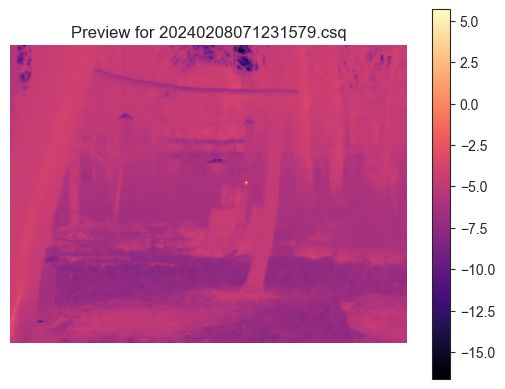

Enter vmin:  -10
Enter vmax:  6


🔄 Writing frames:  12%|█▏        | 2462/19999 [04:34<34:30,  8.47frame/s]/opt/anaconda3/envs/yolo/lib/python3.11/site-packages/exiftool/exiftool.py:551: UserWarning: ExifTool process was previously running but died
  warnings.warn("ExifTool process was previously running but died")
🔄 Writing frames:  59%|█████▉    | 11867/19999 [24:00<16:27,  8.24frame/s]  
2025-07-15 09:32:14,841 - INFO - Processing 2024_02_08-session_0001  — thermal_2



✅ Exported 11868 frames to: Desktop/labeling_data/data_structure/2024_02_08-session_0001 /thermal_1/thermal_-10.0_6.0.mp4
⏱ Approx. duration: 395.60 seconds at 30 fps
Found 1 .csq files in Desktop/labeling_data/data_structure/2024_02_08-session_0001 /thermal_2

Processing [0]: 20240208071227827.csq


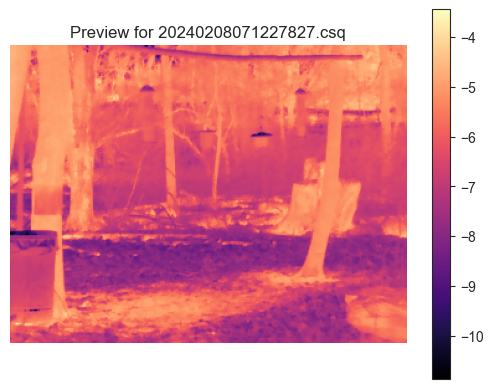

Enter vmin:  -8
Enter vmax:  -4


🔄 Writing frames:  14%|█▍        | 2841/19999 [06:55<44:46,  6.39frame/s]python(86815) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


In [ ]:
# ===== test for one session =====

# Configuration
config = ProcessingConfig(
    src_root_dir=Path("Google Drive/My Drive/fieldwork_data"),
    target_root_dir=Path("Desktop/labeling_data/data_structure"),
    thermal_color='magma',
    preview=True,
    max_frames=20000,
    fps=30,
    target_fps=15,
    max_diff_ms=70000
)

# Initialize processor
processor = AnimalVideoProcessor(config)

print("=== Testing AnimalVideoProcessor ===")
print(f"Source directory: {config.src_root_dir}")
print(f"Target directory: {config.target_root_dir}")
print(f"Target directory exists: {config.target_root_dir.exists()}")

# Test: Get available sessions
print("\n1. Getting available sessions...")
sessions = processor.get_sessions("2024_02_08")
print(f"Found {len(sessions)} sessions:")
for i, session in enumerate(sessions):
    print(f"  {i}: {session.name}")

if sessions:
    test_session = sessions[0]
    
    # Test: Validate session structure
    print(f"\n2. Validating session structure...")
    issues = processor.validate_session_structure(test_session)
    if issues:
        print(f"  Issues found: {issues}")
    else:
        print("  ✅ Session structure is valid")

    
    # Test: Process single session step by step
    print(f"\n3. Processing single testing session: {test_session.name}")
    
    # CSQ Processing
    print("   CSQ Processing...")
    try:
        success = processor.process_session_thermals(test_session, "csq_processing")
        print(f"    CSQ Processing: {'✅ SUCCESS' if success else '❌ FAILED'}")
    except Exception as e:
        print(f"    CSQ Processing: ❌ ERROR - {e}")
    
    # Temporal Alignment
    print("  Temporal Alignment...")
    try:
        success = processor.process_session_thermals(test_session, "temporal_alignment")
        print(f"    Temporal Alignment: {'✅ SUCCESS' if success else '❌ FAILED'}")
    except Exception as e:
        print(f"    Temporal Alignment: ❌ ERROR - {e}")
    
    # # Individual Frame Extraction (thermal only)
    # print("  Individual Frame Extraction (thermal only)...")
    # try:
    #     success = processor.process_session_thermals(test_session, "frame_extraction")
    #     print(f"    Individual Frame Extraction: {'✅ SUCCESS' if success else '❌ FAILED'}")
    # except Exception as e:
    #     print(f"    Individual Frame Extraction: ❌ ERROR - {e}")
    
    # Session-wide Frame Extraction (RGB + thermal)
    print("  Session-wide Frame Extraction (RGB + thermal)...")
    try:
        success = processor.process_session_thermals(test_session, "session_frame_extraction")
        print(f"    Session-wide Frame Extraction: {'✅ SUCCESS' if success else '❌ FAILED'}")
    except Exception as e:
        print(f"    Session-wide Frame Extraction: ❌ ERROR - {e}")
    
    # Test: Complete session processing with new operation
    print(f"\n5. Complete session processing with session-wide frame extraction...")
    try:
        success = processor.process_single_session(
            test_session, 
            operations=["csq_processing", "temporal_alignment", "session_frame_extraction"]
        )
        print(f"  Complete processing: {'✅ SUCCESS' if success else '❌ FAILED'}")
    except Exception as e:
        print(f"  Complete processing: ❌ ERROR - {e}")
    
    # Test: Final session summary
    print(f"\n6. Final session summary for: {test_session.name}")
    summary = processor.get_session_summary(test_session)
    for key, value in summary.items():
        print(f"  {key}: {value}")
    
    # Test: Process all sessions with new operation (commented out for safety)
    print(f"\n7. Testing process_all_sessions with new operation (dry run)...")
    print("  Available operations:")
    print("    - csq_processing")
    print("    - temporal_alignment") 
    print("    - frame_extraction (thermal only)")
    print("    - session_frame_extraction (RGB + thermal)")
    
    # Uncomment the following to run on all sessions:
    # try:
    #     processor.process_all_sessions(
    #         date_pattern="2024_02_08",
    #         operations=["csq_processing", "temporal_alignment", "session_frame_extraction"]
    #     )
    #     print("  Process all sessions: ✅ COMPLETE")
    # except Exception as e:
    #     print(f"  Process all sessions: ❌ ERROR - {e}")

else:
    print("  No sessions found! Check your date pattern and directory structure.")

print("\n=== Test Complete ===")

